# 01 - Khám phá dữ liệu

Notebook này tải dữ liệu Cresci-2017, kiểm tra chất lượng dữ liệu và tạo các biểu đồ cơ bản dễ trình bày.

## Bước 0 - Cấu hình đường dẫn local hoặc Google Colab

Nếu chạy trên Colab, hãy đặt project tại `/content/drive/MyDrive/bot-detection-project`.

In [1]:
from pathlib import Path
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/bot-detection-project')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\Data mining\AnomalyDetection-main


In [2]:
if IN_COLAB:
    %pip install -q -r "{PROJECT_ROOT / 'requirements.txt'}"

## Bước 1 - Tải dữ liệu

In [3]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.preprocess import load_cresci2017

RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

df = load_cresci2017(RAW_DATA_DIR)
display(df.head())

[dữ liệu] Đang tìm Cresci-2017 tại: D:\Data mining\AnomalyDetection-main\data\raw
[dữ liệu] Đã tải genuine_accounts: 3,474 dòng, 44 cột
[dữ liệu] Đã tải social_spambots_1: 991 dòng, 43 cột
[dữ liệu] Đã tải social_spambots_2: 3,457 dòng, 42 cột
[dữ liệu] Đã tải social_spambots_3: 464 dòng, 43 cột
[dữ liệu] Đã tải traditional_spambots_1: 1,000 dòng, 42 cột
[dữ liệu] Đã tải traditional_spambots_4: 1,128 dòng, 42 cột
[dữ liệu] Kích thước sau khi gộp: 10,514 dòng x 44 cột
[dữ liệu] Phân phối nhãn:
label
bot           7040
người thật    3474
Name: count, dtype: int64


,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,url,lang,...,contributors_enabled,following,created_at,timestamp,crawled_at,updated,test_set_1,test_set_2,label,source
0,1502026416,TASUKU HAYAKAWA,0918Bask,2177,208,332,265,1,NaN,ja,...,NaN,NaN,Tue Jun 11 11:20:35 +0000 2013,2013-06-11 13:20:35,2015-05-02 06:41:46,2016-03-15 15:53:47,0.0,0.0,0,genuine_accounts
1,2492782375,ro_or,1120Roll,2660,330,485,3972,5,NaN,ja,...,NaN,NaN,Tue May 13 10:37:57 +0000 2014,2014-05-13 12:37:57,2015-05-01 17:20:27,2016-03-15 15:53:48,0.0,0.0,0,genuine_accounts
2,293212315,bearclaw,14KBBrown,1254,166,177,1185,0,NaN,en,...,NaN,NaN,Wed May 04 23:30:37 +0000 2011,2011-05-05 01:30:37,2015-05-01 18:48:28,2016-03-15 15:53:48,0.0,0.0,0,genuine_accounts
3,191839658,pocahontas farida,wadespeters,202968,2248,981,60304,101,http://t.co/rGV0HIJGsu,en,...,NaN,NaN,Fri Sep 17 14:02:10 +0000 2010,2010-09-17 16:02:10,2015-05-01 13:55:16,2016-03-15 15:53:48,0.0,0.0,0,genuine_accounts
4,3020965143,Ms Kathy,191a5bd05da04dc,82,21,79,5,0,NaN,en,...,NaN,NaN,Fri Feb 06 04:10:49 +0000 2015,2015-02-06 05:10:49,2015-05-02 01:17:32,2016-03-15 15:53:48,0.0,0.0,0,genuine_accounts


## Bước 2 - Kích thước, kiểu dữ liệu và dữ liệu thiếu

In [4]:
print(f'Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]:,} cột')
display(df.dtypes.to_frame('kiểu dữ liệu'))

missing = pd.DataFrame({
    'số giá trị thiếu': df.isna().sum(),
    'tỷ lệ thiếu (%)': df.isna().mean().mul(100).round(2),
}).sort_values('số giá trị thiếu', ascending=False)
display(missing.head(20))

Kích thước dữ liệu: 10,514 dòng x 44 cột


,kiểu dữ liệu
id,int64
name,str
screen_name,str
statuses_count,int64
followers_count,int64
friends_count,int64
favourites_count,int64
listed_count,int64
url,str
lang,object


,số giá trị thiếu,tỷ lệ thiếu (%)
follow_request_sent,10514,100.00
following,10514,100.00
contributors_enabled,10514,100.00
notifications,10514,100.00
is_translator,10513,99.99
verified,10503,99.90
default_profile_image,10451,99.40
protected,10436,99.26
default_profile,9141,86.94
url,7439,70.75


## Bước 3 - Phân phối tài khoản người thật và bot

C:\Users\Danh\AppData\Local\Temp\ipykernel_4768\1460317155.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Loại tài khoản')


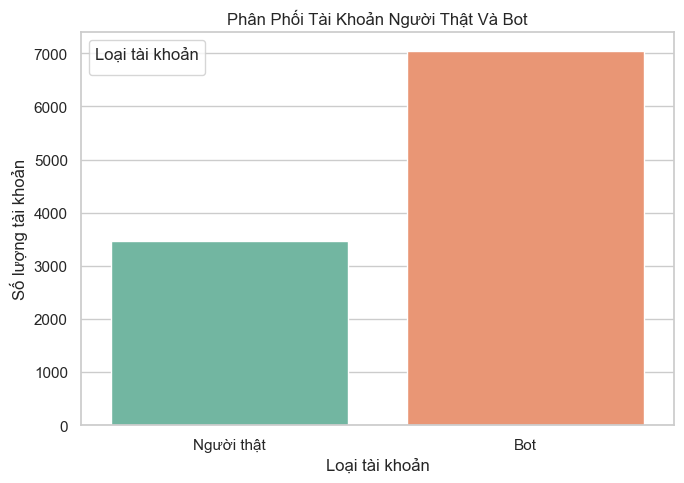

In [5]:
plot_df = df.copy()
plot_df['loại tài khoản'] = plot_df['label'].map({0: 'Người thật', 1: 'Bot'})

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=plot_df, x='loại tài khoản', hue='loại tài khoản', palette='Set2', ax=ax)
ax.set_title('Phân Phối Tài Khoản Người Thật Và Bot')
ax.set_xlabel('Loại tài khoản')
ax.set_ylabel('Số lượng tài khoản')
ax.legend(title='Loại tài khoản')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'class_dist.png', dpi=150)
plt.show()

## Bước 4 - Phân tích mối quan hệ giữa Followers và Friends (Scatter Plot)


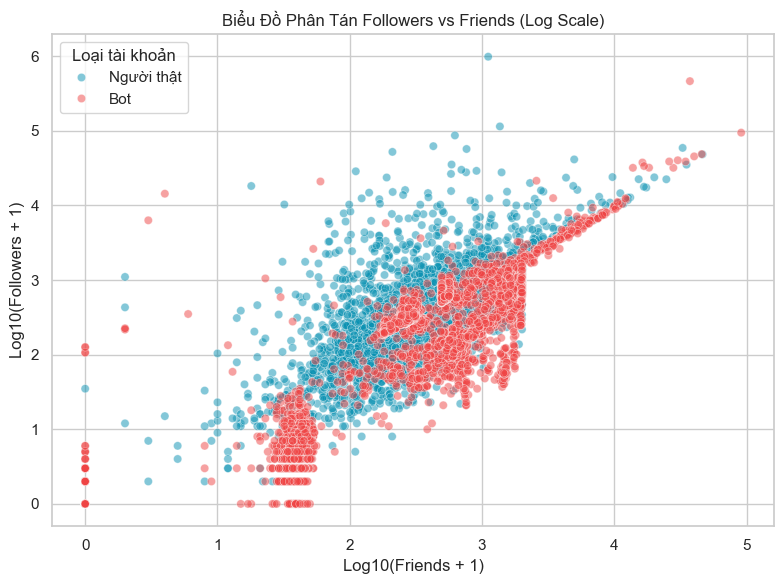

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.copy()
plot_df['loại tài khoản'] = plot_df['label'].map({0: 'Người thật', 1: 'Bot'})
plot_df['log_friends'] = np.log10(plot_df['friends_count'] + 1)
plot_df['log_followers'] = np.log10(plot_df['followers_count'] + 1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df, 
    x='log_friends', 
    y='log_followers', 
    hue='loại tài khoản', 
    alpha=0.5, 
    palette={'Người thật': '#0891b2', 'Bot': '#ef4444'},
    ax=ax
)
ax.set_title('Biểu Đồ Phân Tán Followers vs Friends (Log Scale)')
ax.set_xlabel('Log10(Friends + 1)')
ax.set_ylabel('Log10(Followers + 1)')
ax.legend(title='Loại tài khoản')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'followers_friends_scatter.png', dpi=150)
plt.show()

## Nhận xét chính

- Dữ liệu gồm tài khoản người thật và nhiều nhóm bot khác nhau.
- Biểu đồ phân tán chỉ ra hành vi rõ rệt: bot thường có lượng Friends rất lớn (đi follow dạo) nhưng Followers cực kỳ thấp. Người thật nằm chủ yếu ở phần phía trên bên trái (Friends ít hoặc vừa phải nhưng Followers cao).
- Sự phân tách rõ ràng này chứng tỏ mối quan hệ giữa Followers và Friends là một đặc trưng phân loại bot cực kỳ mạnh mẽ.